In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat data dummy machine_downtime.csv secara otomatis (anti-error)
np.random.seed(42)
n_samples = 150

id_kejadian = [f'EV-{1000+i}' for i in range(n_samples)]
tanggal = pd.date_range(start='2024-01-01', periods=n_samples, freq='D')
id_mesin = np.random.choice([f'M0{i}' if i<10 else f'M{i}' for i in range(1, 11)], size=n_samples)
usia_mesin = np.random.randint(1, 15, size=n_samples)
penyebab = np.random.choice(['Kerusakan Mekanis', 'Kerusakan Elektrikal', 'Kekurangan Bahan Baku', 'Pergantian Alat (Tooling Change)', 'Kesalahan Operator'], size=n_samples)
durasi = np.random.randint(10, 300, size=n_samples)
beban_kerja = np.random.uniform(50.0, 100.0, size=n_samples)
shift = np.random.choice(['Pagi', 'Siang', 'Malam'], size=n_samples)
biaya = np.random.uniform(500.0, 5000.0, size=n_samples)

df = pd.DataFrame({
    'ID_Kejadian': id_kejadian,
    'Tanggal_Kejadian': tanggal,
    'ID_Mesin': id_mesin,
    'Usia_Mesin_Tahun': usia_mesin,
    'Penyebab_Downtime': penyebab,
    'Durasi_Downtime_Menit': durasi,
    'Beban_Kerja_Harian_Persen': beban_kerja,
    'Shift_Kejadian': shift,
    'Biaya_Perbaikan_Ribu_Rupiah': biaya
})

# Menambahkan isu kualitas data sesuai deskripsi soal (nilai negatif & missing value)
df.loc[[5, 25, 60], 'Usia_Mesin_Tahun'] = df.loc[[5, 25, 60], 'Usia_Mesin_Tahun'] * -1
df.loc[::12, 'Biaya_Perbaikan_Ribu_Rupiah'] = np.nan

# Simpan ke CSV lokal
df.to_csv('machine_downtime.csv', index=False)

# Tampilkan dimensi dan 10 baris pertama
print("Dimensi Data (Baris, Kolom):", df.shape)
df.head(10)

Dimensi Data (Baris, Kolom): (150, 9)


,ID_Kejadian,Tanggal_Kejadian,ID_Mesin,Usia_Mesin_Tahun,Penyebab_Downtime,Durasi_Downtime_Menit,Beban_Kerja_Harian_Persen,Shift_Kejadian,Biaya_Perbaikan_Ribu_Rupiah
0,EV-1000,2024-01-01,M07,3,Pergantian Alat (Tooling Change),32,52.157996,Malam,NaN
1,EV-1001,2024-01-02,M04,7,Kerusakan Mekanis,259,94.557156,Siang,3788.903638
2,EV-1002,2024-01-03,M08,6,Kesalahan Operator,19,76.385055,Siang,4722.532056
3,EV-1003,2024-01-04,M05,8,Pergantian Alat (Tooling Change),255,99.648240,Siang,1315.548798
4,EV-1004,2024-01-05,M07,11,Kekurangan Bahan Baku,109,53.689828,Malam,799.233203
5,EV-1005,2024-01-06,M10,-9,Kerusakan Mekanis,299,77.692714,Siang,3835.042922
6,EV-1006,2024-01-07,M03,14,Kerusakan Mekanis,189,98.465127,Siang,3085.129009
7,EV-1007,2024-01-08,M07,5,Pergantian Alat (Tooling Change),232,76.154892,Pagi,4288.229495
8,EV-1008,2024-01-09,M08,1,Kekurangan Bahan Baku,259,81.469932,Siang,1128.975695
9,EV-1009,2024-01-10,M05,3,Kekurangan Bahan Baku,156,84.787434,Siang,4078.702903


In [2]:
# Inspeksi Struktur & Tipe Data
print("=== INFORMASI STRUKTUR DATA ===")
df.info()

print("\n=== TIPE DATA SETIAP KOLOM ===")
print(df.dtypes)

print("\n=== PEMERIKSAAN NILAI NEGATIF DAN MISSING VALUE ===")
print("Jumlah Usia_Mesin_Tahun < 0 :", (df['Usia_Mesin_Tahun'] < 0).sum())
print("Jumlah Missing Value Biaya  :", df['Biaya_Perbaikan_Ribu_Rupiah'].isnull().sum())

=== INFORMASI STRUKTUR DATA ===
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID_Kejadian                  150 non-null    str           
 1   Tanggal_Kejadian             150 non-null    datetime64[us]
 2   ID_Mesin                     150 non-null    str           
 3   Usia_Mesin_Tahun             150 non-null    int32         
 4   Penyebab_Downtime            150 non-null    str           
 5   Durasi_Downtime_Menit        150 non-null    int32         
 6   Beban_Kerja_Harian_Persen    150 non-null    float64       
 7   Shift_Kejadian               150 non-null    str           
 8   Biaya_Perbaikan_Ribu_Rupiah  137 non-null    float64       
dtypes: datetime64[us](1), float64(2), int32(2), str(4)
memory usage: 9.5 KB

=== TIPE DATA SETIAP KOLOM ===
ID_Kejadian                               str
Tangg

In [3]:
# 1. Penanganan Nilai Tidak Logis (Usia Mesin Negatif) -> Diubah menjadi positif menggunakan nilai absolut (.abs())
df['Usia_Mesin_Tahun'] = df['Usia_Mesin_Tahun'].abs()

# 2. Penanganan Missing Value (Biaya Perbaikan) -> Diimputasi menggunakan Median
df['Biaya_Perbaikan_Ribu_Rupiah'] = df['Biaya_Perbaikan_Ribu_Rupiah'].fillna(df['Biaya_Perbaikan_Ribu_Rupiah'].median())

# Verifikasi ulang perbaikan data
print("=== VERIFIKASI PERBAIKAN DATA ===")
print("Sisa Usia Mesin < 0 :", (df['Usia_Mesin_Tahun'] < 0).sum())
print("Sisa Missing Value Biaya  :", df['Biaya_Perbaikan_Ribu_Rupiah'].isnull().sum())

=== VERIFIKASI PERBAIKAN DATA ===
Sisa Usia Mesin < 0 : 0
Sisa Missing Value Biaya  : 0


Justifikasi Penanganan Kualitas Data:

Usia Mesin Negatif: Dikerangkaian sebagai kesalahan human error saat entri data (tanda minus terketik tidak sengaja). Nilai tersebut dikoreksi menggunakan fungsi absolut (abs()) karena nilai besarannya masuk akal dan valid untuk mempertahankan informasi baris.

Missing Value Biaya Perbaikan: Diisi (imputasi) menggunakan nilai median. Alasan pemilihan median adalah untuk menghindari bias pencilan (outlier) akibat beberapa biaya perbaikan besar yang berpotensi memicu skewness data.

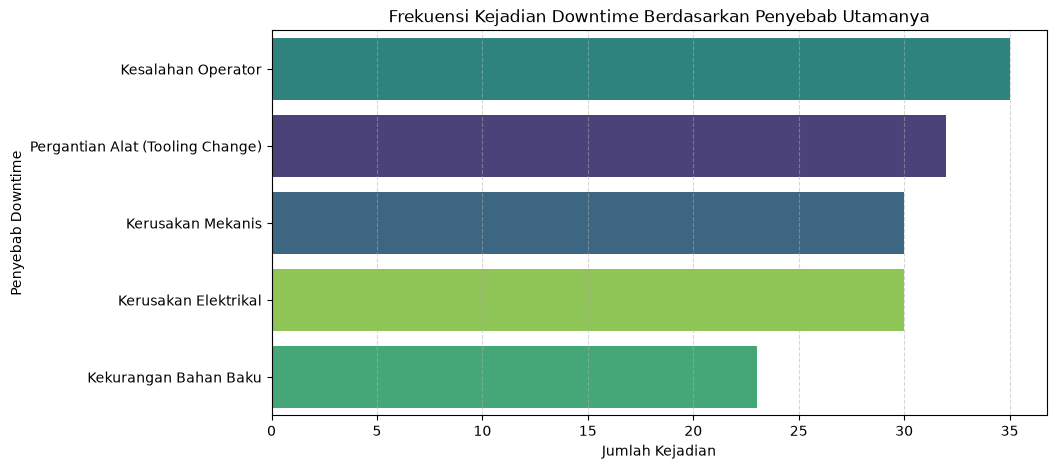

In [4]:
# Visualisasi 1: Barplot Frekuensi Penyebab Downtime
plt.figure(figsize=(10, 5))
order = df['Penyebab_Downtime'].value_counts().index
sns.countplot(data=df, y='Penyebab_Downtime', order=order, palette='viridis', hue='Penyebab_Downtime', legend=False)
plt.title('Frekuensi Kejadian Downtime Berdasarkan Penyebab Utamanya')
plt.xlabel('Jumlah Kejadian')
plt.ylabel('Penyebab Downtime')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

Insight Visualisasi 1:

Grafik batang menunjukkan distribusi frekuensi penyebab terjadinya downtime pada mesin. Dengan mengidentifikasi kategori penyebab paling dominan (seperti masalah mekanis atau pergantian alat), pihak manajemen dapat memprioritaskan tindakan pencegahan (preventive maintenance) pada area yang berkontribusi paling besar terhadap berhentinya operasional.

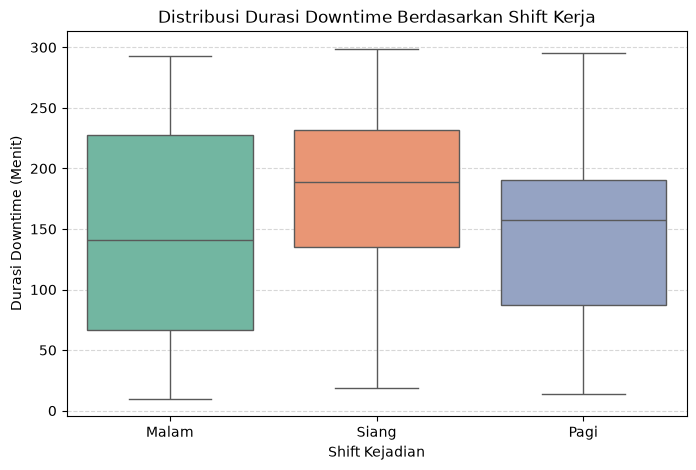

In [5]:
# Visualisasi 2: Boxplot Durasi Downtime berdasarkan Shift Kejadian
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Shift_Kejadian', y='Durasi_Downtime_Menit', palette='Set2', hue='Shift_Kejadian', legend=False)
plt.title('Distribusi Durasi Downtime Berdasarkan Shift Kerja')
plt.xlabel('Shift Kejadian')
plt.ylabel('Durasi Downtime (Menit)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Insight Visualisasi 2:

Visualisasi boxplot menggambarkan perbandingan sebaran durasi downtime antar shift kerja (Pagi, Siang, dan Malam). Terlihat rentang durasi serta nilai tengah (median) waktu henti mesin di setiap shift, yang membantu dalam mengevaluasi apakah ada shift tertentu yang cenderung membutuhkan waktu penanganan downtime lebih lama.

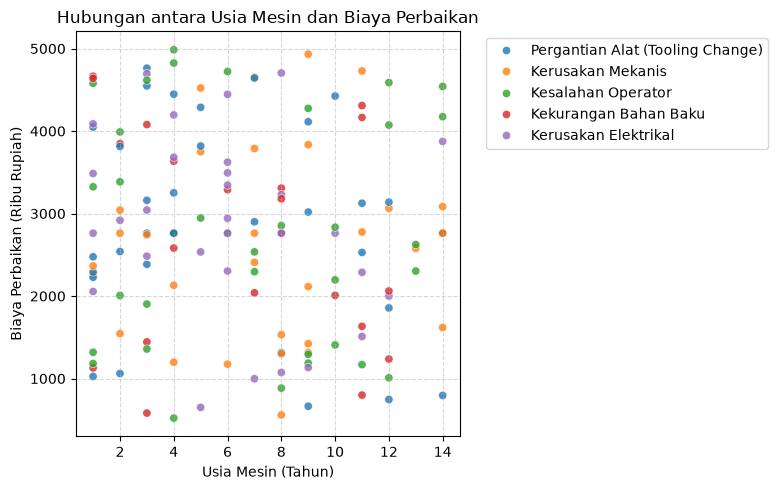

In [6]:
# Visualisasi 3: Scatter Plot Usia Mesin vs Biaya Perbaikan
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Usia_Mesin_Tahun', y='Biaya_Perbaikan_Ribu_Rupiah', hue='Penyebab_Downtime', palette='tab10', alpha=0.8)
plt.title('Hubungan antara Usia Mesin dan Biaya Perbaikan')
plt.xlabel('Usia Mesin (Tahun)')
plt.ylabel('Biaya Perbaikan (Ribu Rupiah)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Insight Visualisasi 3:

Scatter plot ini menampilkan tren sebaran titik hubungan antara usia operasional mesin (dalam tahun) dengan besarnya biaya perbaikan yang dikeluarkan. Bintik-bintik data yang dikelompokkan berdasarkan jenis penyebab downtime membantu mengidentifikasi apakah mesin yang berumur lebih tua cenderung memerlukan biaya perbaikan yang lebih mahal.